In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_11008\4216590154.py:4: DtypeWarning: Columns (0: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")


Time Trends

This looks at how lending and defaults changed over time.

In [6]:
df["issue_d"].head()


0    Dec-2018
1    Dec-2018
2    Dec-2018
3    Dec-2018
4    Dec-2018
Name: issue_d, dtype: str

In [8]:
df["issue_d"] = pd.to_datetime(
    df["issue_d"],
    format="%b-%Y",
    errors="coerce"
)

Number of loans issued over time, showing after every year

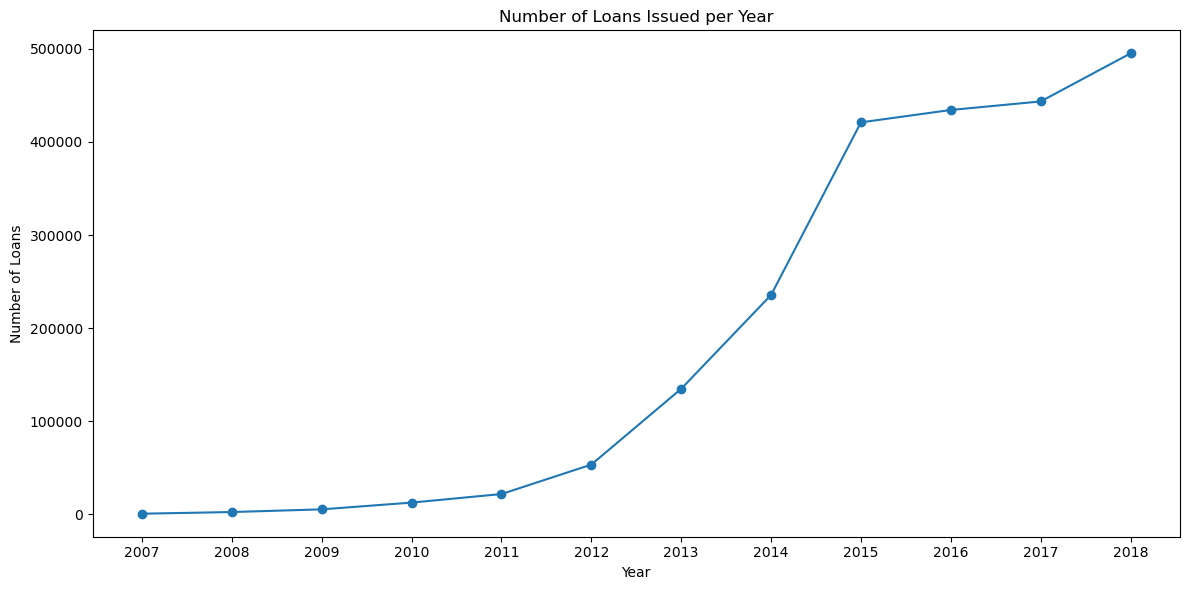

In [12]:
loans_over_year = (
    df
    .groupby(df["issue_d"].dt.year)
    .size()
)

plt.figure(figsize=(12, 6))

plt.plot(
    loans_over_year.index,
    loans_over_year.values,
    marker="o"
)

plt.title("Number of Loans Issued per Year")
plt.xlabel("Year")
plt.ylabel("Number of Loans")

plt.xticks(loans_over_year.index)

plt.tight_layout()
plt.show()

Average interest rate over time

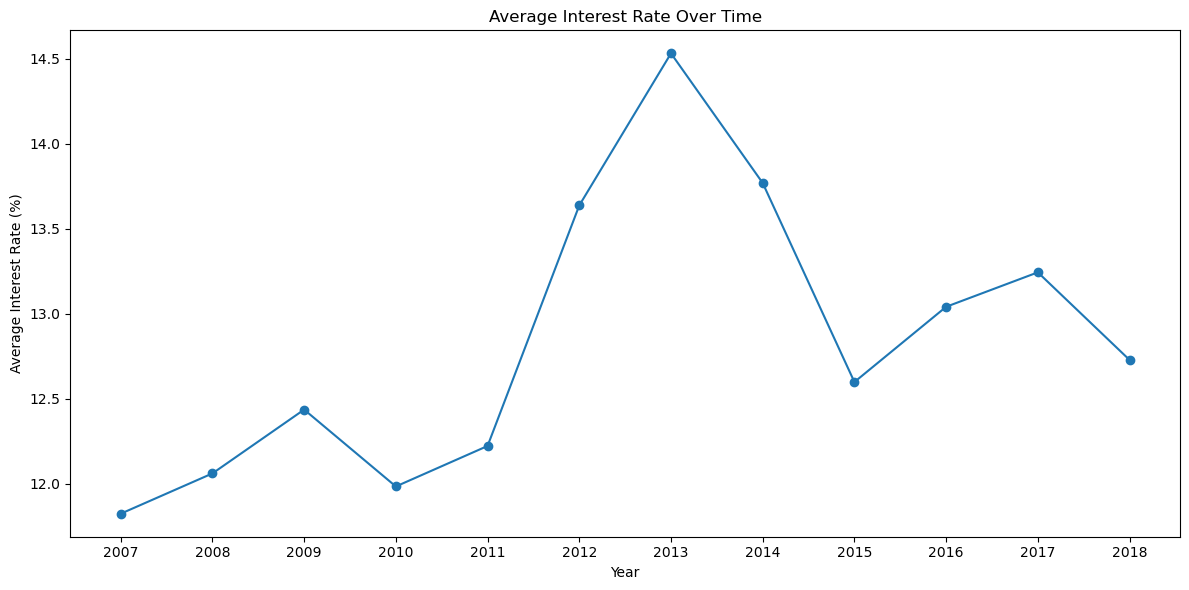

In [15]:
interest_over_year = (
     df
    .groupby(df["issue_d"].dt.year)["int_rate"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    interest_over_year.index,
    interest_over_year.values,
    marker="o"
)

plt.title("Average Interest Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Interest Rate (%)")

plt.xticks(interest_over_year.index)

plt.tight_layout()
plt.show()

Default rate over time

In [16]:
finalized_loans = df[
    df["default_status"].isin(
        ["Defaulted", "Did Not Default"]
    )
].copy()

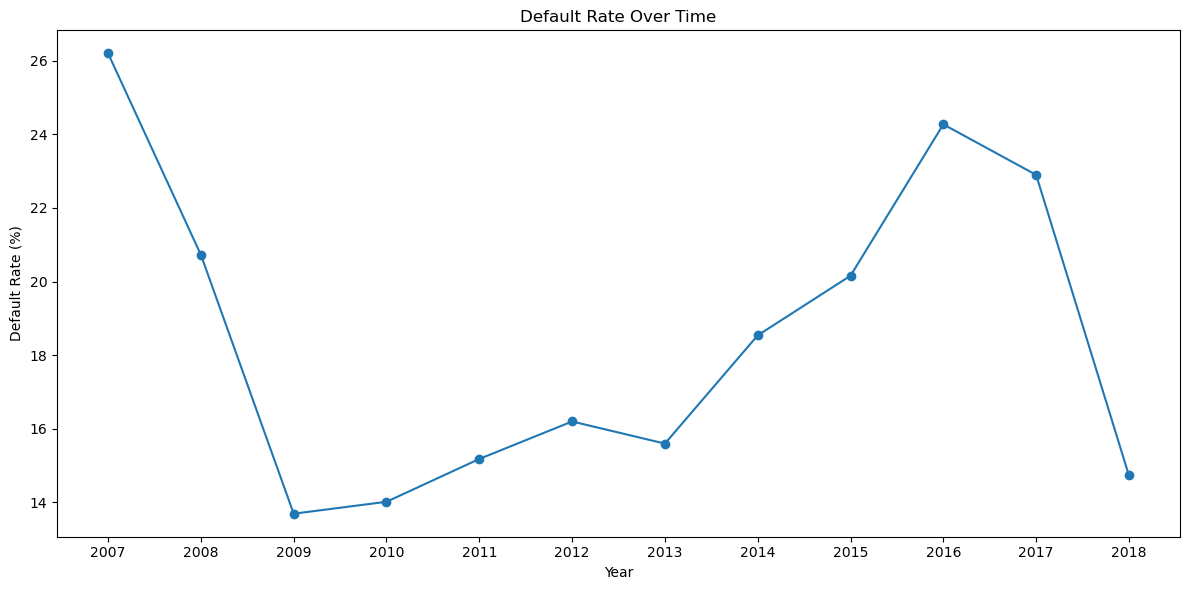

In [17]:
default_over_year = (
    finalized_loans
    .groupby(
        finalized_loans["issue_d"].dt.year
    )["default_status"]
    .apply(lambda x: (x == "Defaulted").mean() * 100)
)

plt.figure(figsize=(12, 6))

plt.plot(
    default_over_year.index,
    default_over_year.values,
    marker="o"
)

plt.title("Default Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")

plt.xticks(default_over_year.index)

plt.tight_layout()
plt.show()